конспект ML. Выполнил Павлов Д.Н. (2024 г.)

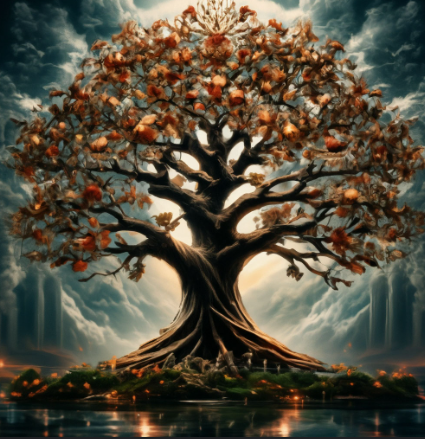

# Decision Trees

**Решающие деревья** (Decision Trees) — это алгоритм машинного обучения, который принимает решения, исходя из последовательных вопросов о данных. Давайте приведем аналогию.

Представьте, что вы пришли к врачу с жалобой "плохое самочувствие". Задача врача - поставить точный диагноз. Какие действия он предпринимает? Первоочередным является сбор анамнеза и выявление симптоматики. Симптомы - это Признаки, Синдром - это некоторые закономерности и патогенетические взаимосвязи симптомов, а диагноз - целевое значение. Итак, представьте диалог:
- Беспокоят ли вас боли в подвздошной области и внизу живота?
  * Если нет, то исключаем Аппендицит.
- Есть ли температура?
  * Да - есть воспалительный процесс
- Болит ли горло?
  * Если Да - воспаление ВДП.
- Боль при глотании, гнойные образования на задней стенке?
  * Да! У Вас Ангина!

Диагноз поставлен!

Диалог строится как цепь уточняющих вопросов от более общих к более частным, где на каждом этапе исключаются одни предположения о диагнозе и последовательно уточняется наиболее вероятное заболевание.

Примерно так и работает решающее дерево. Алгоритм можно представить в виде логической структуры, похожей на граф, где каждый шаг — это проверка какого-либо условия. В итоге в общем виде дерево помогает разделить данные на группы, которые соответствуют возможным решениям или прогнозам.

В отличие от **линейных моделей**, которые полагаются на простые математические уравнения для поиска взаимосвязей, решающие деревья принимают решения, основываясь на логических условиях. Это позволяет им обрабатывать сложные и нелинейные зависимости, что делает их более гибкими в случаях, когда данные трудно описать с помощью прямых или плоскостей.

Будет очень не лишним изучить [статью от `sklearn`](https://scikit-learn.org/stable/modules/tree.html#tree).

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
import pydotplus
from IPython.display import Image
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output

# make a plotting function
def plot_tree(decision_tree, column_names, width=1500):
    dot_data = tree.export_graphviz(decision_tree,
                                out_file=None,
                                feature_names=column_names)

    graph = pydotplus.graph_from_dot_data(dot_data)


    return Image(graph.create_png(), width=width)

In [ ]:
df = sns.load_dataset('iris')

In [ ]:
df

In [ ]:
df.species.unique()

In [ ]:
df = df.loc[df.species.isin(['versicolor', 'virginica']), ['petal_length',	'petal_width', 'species']]

In [ ]:
df.head(3)

In [ ]:
sns.scatterplot(x=df.petal_length, y=df.petal_width, hue=df.species)

Чтобы показать принцип работы решающего дерева, формализуем задачу. Перед нами хорошо известный датасет "Ирисы Фишера". Отберем из него два вида цветка и два признака чтобы смоделировать задачу бинарной классификации. Этот пример наилучшим образом даст представление о том, как работает новый алгоритм. Видим картину условной линейной разделимости с частичным перекрыванием классов. Линейное разделение неизбежно даст некоторый процент ошибок, однако, если отбросить проблему "переобучения", дерево способно разделить классы со 100% точностью. Это может быть как преимуществом, так и проблемой. Как же оно работает?

In [ ]:
sns.scatterplot(x=df.petal_length, y=df.petal_width, hue=df.species)
plt.axhline(1.75, color='red', linestyle='dashed')
plt.plot(np.array([5.25, 5.25]), np.array([1, 1.75]), '--r')
plt.plot(np.array([4.55, 4.55]), np.array([1, 1.75]), '--r')
plt.plot(np.array([3, 4.55]), np.array([1.65, 1.65]), '--r')
plt.plot(np.array([4.55, 5.25]), np.array([1.55, 1.55]), '--r')
plt.plot(np.array([4.55, 5.25]), np.array([1.45, 1.45]), '--r')
plt.plot(np.array([4.95, 4.95]), np.array([1.45, 1.55]), '--r')

Если данное признаковое пространство "Нарезать" на области многократно применяя "Разделение" выбрав соответствующий Признак и "Порог", то увидим, что каждый объект может быть однозначно проклассифицирован. На данном изображении мы видим границы, значения для которых мы подобрали "руками".

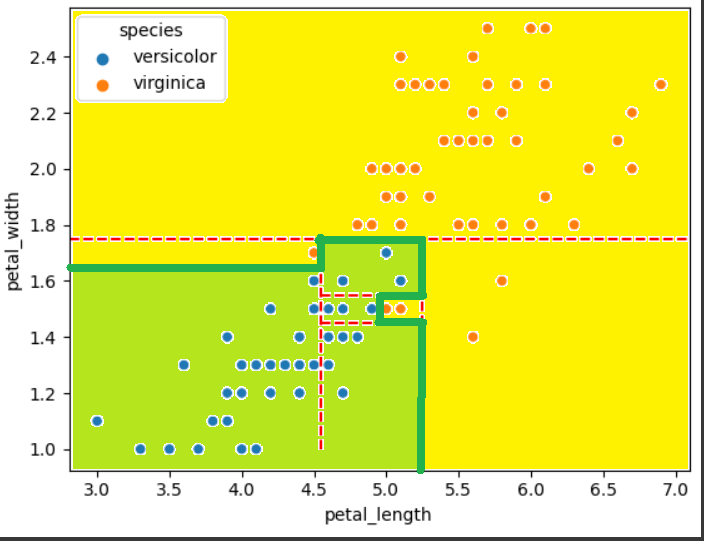

Формально, для отделения класса `virginica` набор границ можно записать в виде булевых операций:

```
(petal_length< 4.55 & petal_width > 1.65) | (4.55 < petal_length< 5.25 & petal_width > 1.75) | (petal_length > 5.25 & petal_width > 0) | (4.95 < petal_length< 5.25 & 1.45 < petal_width < 1.55)
```



$\left[
      \begin{gathered}
        \begin{cases}
          petal\;\;length < 4.55       \\
          petal\;\;width > 1.65
        \end{cases} \\
                \begin{cases}
          4.55 < petal\;\;length< 5.25       \\
          petal\;\;width > 1.75
        \end{cases} \\
                \begin{cases}
          petal\;\;length > 5.25       \\
          petal\;\;width > 0
        \end{cases} \\
                \begin{cases}
          4.95 < petal\;\;length< 5.25       \\
          petal\;\;width < 1.55
        \end{cases} \\
      \end{gathered}
\right.$

Пропишем данные условия в виде настоящего кода:

In [ ]:
df['species_pred'] = df.apply(lambda i: 'virginica' if
         (i['petal_length']< 4.55 and i['petal_width'] > 1.65) or
         (4.55 < i['petal_length']< 5.25 and i['petal_width'] > 1.75) or
         (i['petal_length'] > 5.25 and i['petal_width'] > 0) or
         (4.95 < i['petal_length']< 5.25 and 1.45 < i['petal_width'] < 1.55)
         else 'versicolor' , axis=1)

In [ ]:
df

На основании описанного выше Булевого условия сделали прогноз и теперь оценим его точность:

In [ ]:
print(f'Accuracy score: {(df.species == df.species_pred).sum() / df.shape[0]}')

Обратите внимание: одну ошибку мы всё же допустили — идеального разделения «руками» добиться сложно. Дальше увидим, как алгоритм подбирает пороги автоматически.

Какая эвристика используется для более эффективного разбиения? Этот процесс поэтапный, формулируемый как "От общего к частному, от глобальнгого к мелочам!" Самое первое разделение мы делаем таким образом, чтобы отделить разом максимальное количество объектов одного класса. С другой стороны границы останутся представители обоих классов и с ними поступаем также. Таким образом речь идет о рекурсивном алгоритме. Он может продолжаться до тех пор пока классы не будут поделены полностью или же остановиться при условии какого-либо критерия остановки. Напишем псевдокод данного алгоритма:

```
Функция ПостроитьДерево(Данные):

    1. Найти такое разделение данных по какому-либо признаку, которое максимизирует количество объектов одного класса в одной группе.
    
    2. Если группа данных содержит объекты разных классов:
        2.1. Для каждой подгруппы данных:
            2.1.1. Найти такое разделение подгруппы по другому признаку, которое максимально отделяет объекты одного класса.
            2.1.2. Повторить этот процесс для каждой подгруппы.
    
    3. Повторять процесс для каждой подгруппы, пока в каждой из них не останутся только объекты одного класса.
    
    4. Вернуть структуру дерева с признаками разбиения и соответствующими подгруппами.
```


Как выглядят этапы разбиений для нашего случая:

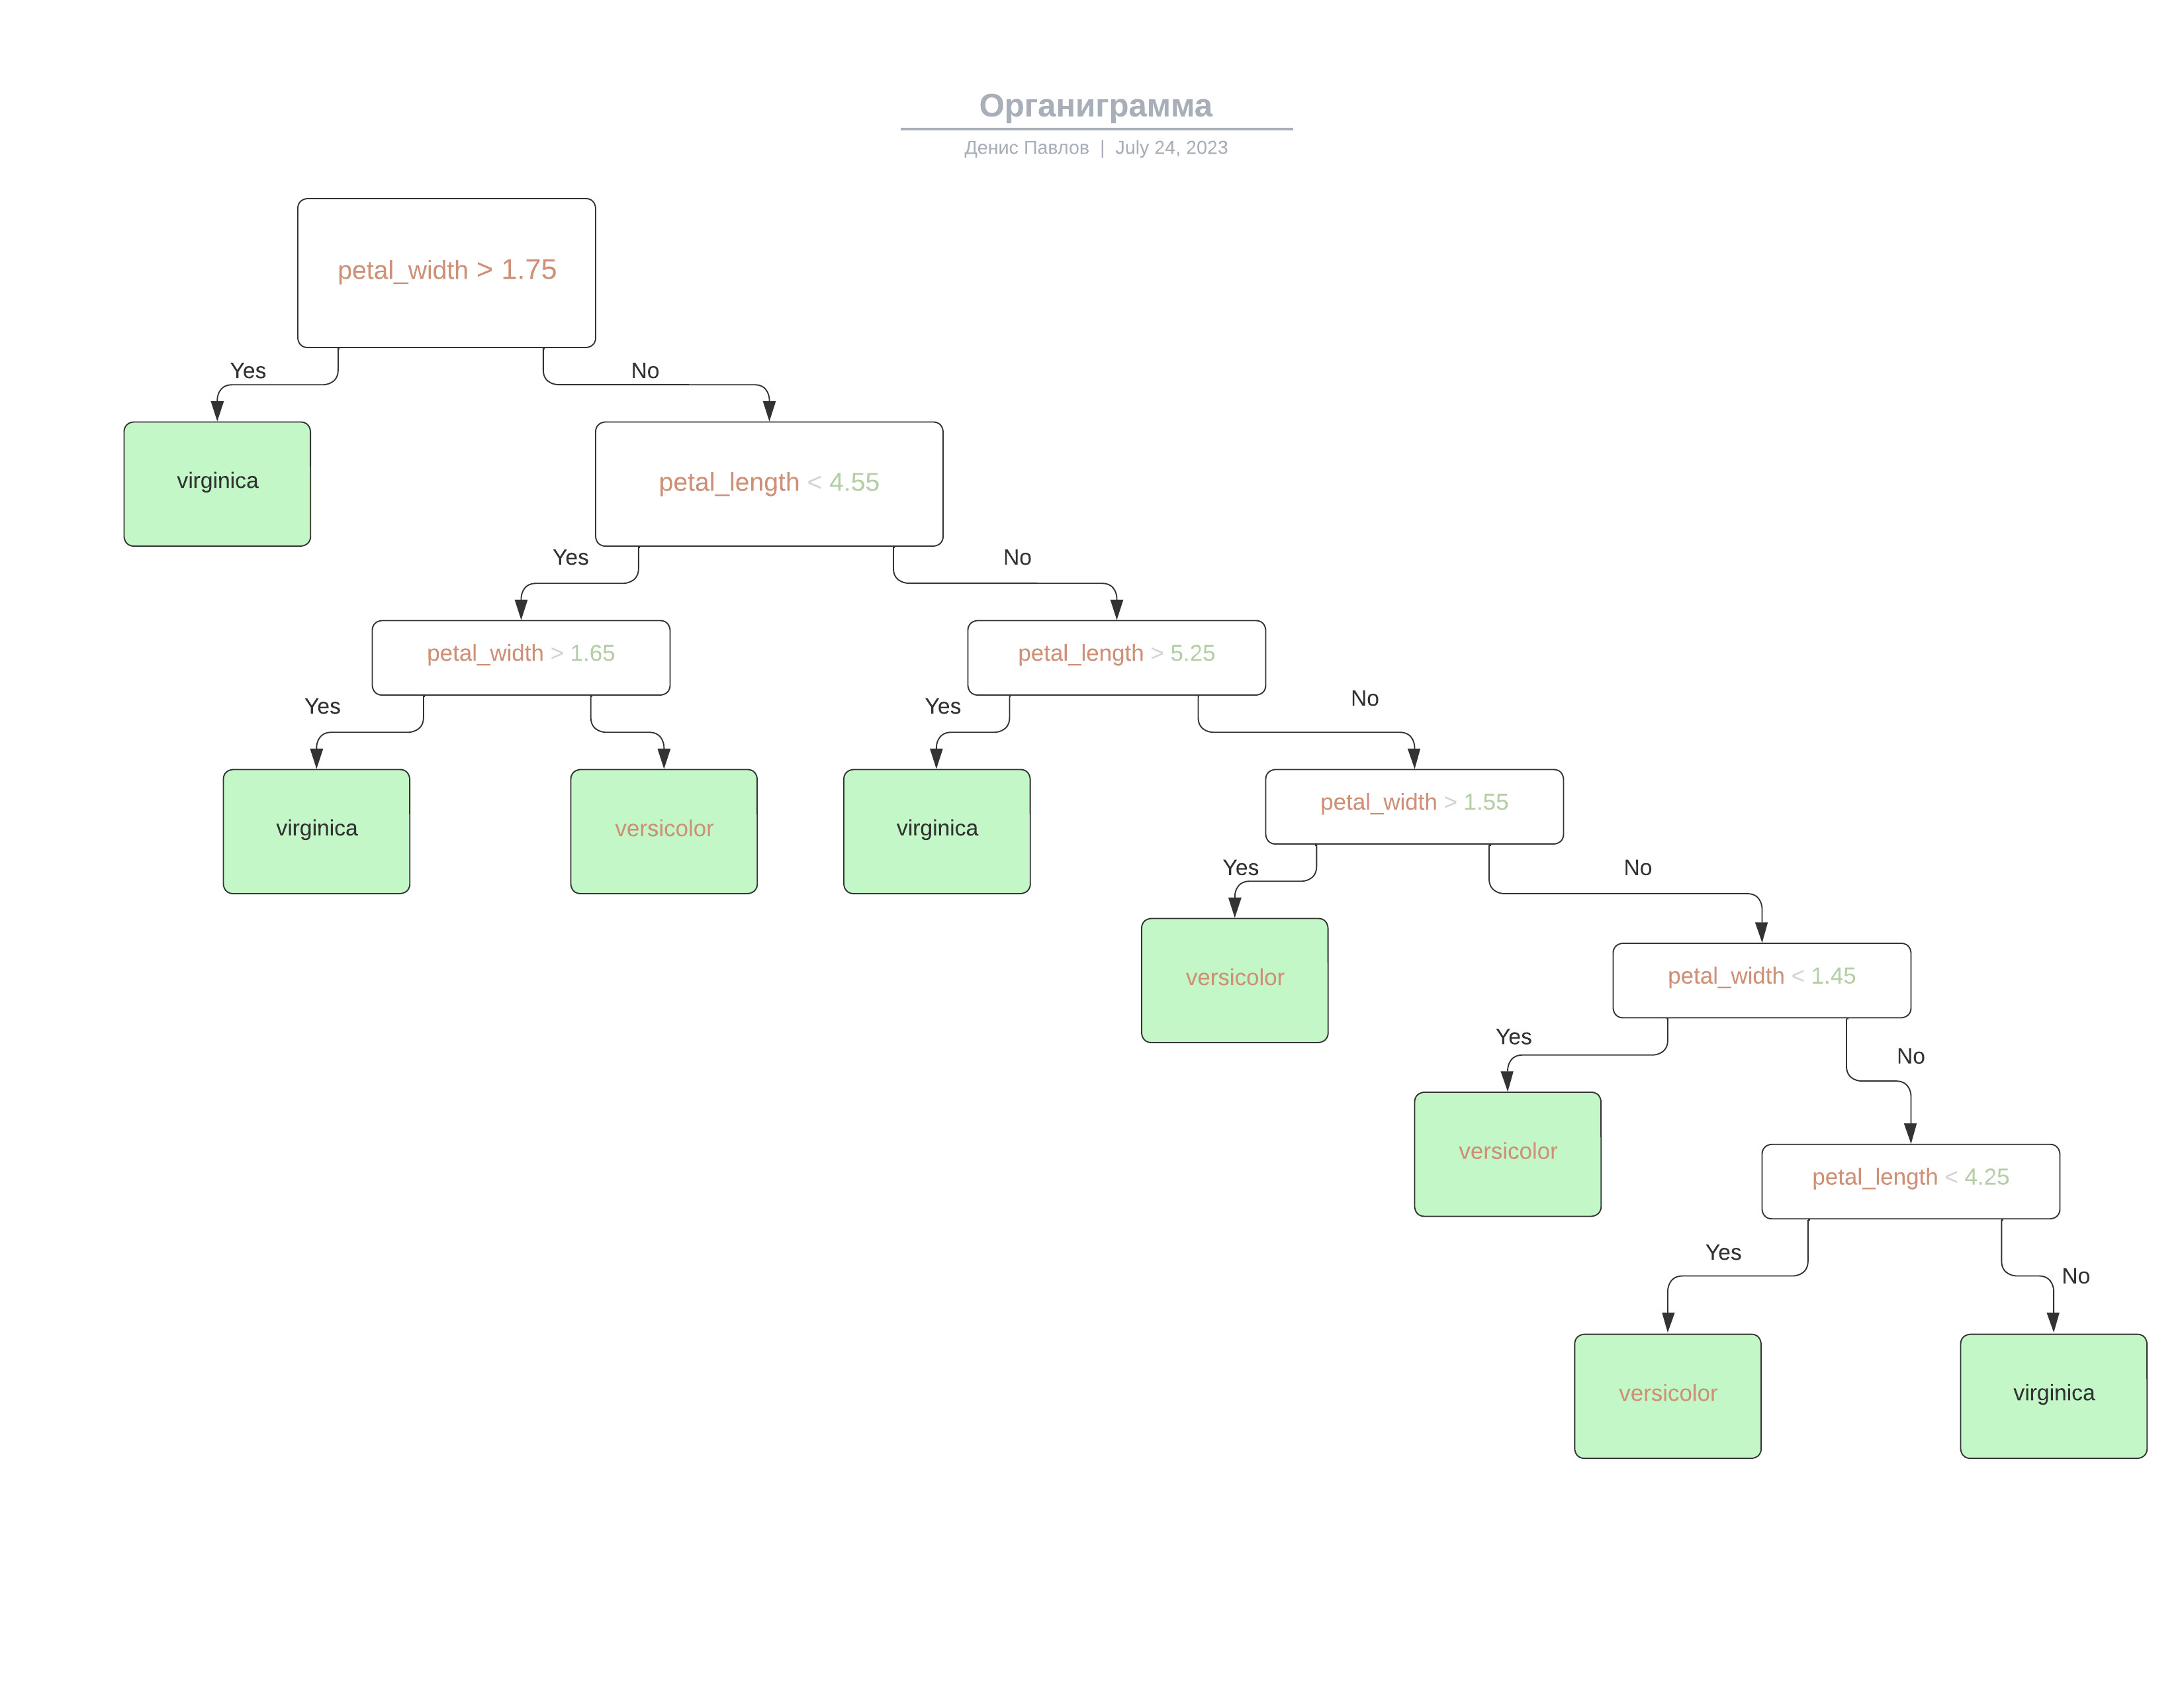

Данная структура и есть "Дерево решений". На схеме присутствуют основные характерные объекты. Введем терминологию:


1. **Корневой узел** — это первый узел в решающем дереве, с которого начинается процесс разделения данных. Он представляет собой исходную точку, где принимается первое решение на основе выбранного признака. Все остальные узлы в дереве исходят из этого корневого узла. В корневом узле обязательно присутствуют:
  * Наименование признака по которому берется порог
  * Значение порога
  * Метрика качества разбиения (В готовых алгоритмах)

2. **Вершина** — это любая точка (узел) в решающем дереве, которая следует за **Корневым узлом** или другой Вершиной и в ней происходит разделение только по тем объектам, которые прошли в эту вершину по бинарному(-ым) условию(-ям) родительской(-их) вершины(вершин) или корневого узла. В вершине также обязательно присутствуют:
  * Наименование признака по которому берется порог
  * Значение порога
  * Метрика качества разбиения (В готовых алгоритмах)

3. **Лист** — это конечный узел в дереве, в котором больше не происходит разделение. Лист содержит итоговое решение или прогноз, который был получен на основе предыдущих разбиений. В случае задачи классификации, лист указывает на предсказанный класс, а в задаче регрессии — на числовое значение. В идеальном (чаще переобученном) случае лист содержит объекты только одного класса или значения, которые очень близки к TRUE-значениям целевой переменной в случае задачи регрессии.

4. **Слой** - новое "поколение" дочерних узлов или концевых верширн (листьев). Количество слоев - это основная характеристика дерева, именуемая "ГЛУБИНА". В нашем случае глубина равна 6.

Именно поэтому дерево также в общем смысле называют ЛОГИЧЕСКИМ ГРАФОМ.

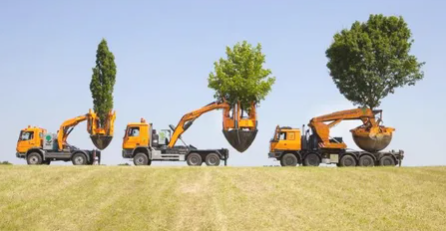

# Как автоматизировать процесс построения дерева?

В первом примере мы решали задачу «руками», подбирая пороги разбиения интуитивно, с оглядкой на диаграмму рассеяния. Но, как всегда, этот процесс хочется автоматизировать. Для выбора признака разбиения и порога по нему мы оптимизируем некоторый критерий наилучшего разбиения (функционал качества разбиения), чтобы процесс был максимально эффективным. Да, ML — это постоянно про оптимизацию... Что же это за критерии?

> **Важно:** алгоритм построения дерева — **жадный**. На каждом шаге он выбирает локально лучшее разбиение и никогда не пересматривает прошлые решения. Построение глобально оптимального дерева — NP-трудная задача, поэтому на практике всегда используют именно жадную эвристику.

# Критерии разбиения и функционал качества разбиения

$H(R)$ - мера "неоднородности" или "неопределенности" множества $R$, являющегося полной группой.

Пусть мы решаем задачу классификации на $K$ классов, и $[p_1, p_2, ..., p_k]$ - доли объектов (вероятности) классов $1, 2, ..., k$ во множестве $R$. Тогда мерами неопределенности могут быть:


1. **Misclassification criterion** (критерий ошибочной классификации):
$$H(R) = 1 - p_{max}$$

2. **Entropy criterion** (критерий энтропии):
$$H(R) = -\sum_{k=1}^{K} p_k \ln p_k$$

3. **Gini criterion** (критерий Джини):

$$H(R) = \sum_{k=1}^{K} p_k(1-p_k)$$

Эти формулы описывают три различных подхода к измерению неоднородности множества данных $R$ при классификации.

Ниже вы увидите иллюстрацию того, как работают критерии неоднородности для некоторого множества представленного двумя классами. Поиграйтесь данным симулятором. Вы сможете увидеть, что критерий неоднородности принимает максимальное значение в ситуации, когда классы представлены равным количеством объектов, и нулевое значение, когда выборка представлена только одним единственным классом. Это одинаково работает для любого количества классов.

In [ ]:
# @title Код отрисовки графика
from ipywidgets import interact, IntSlider

X = np.array([[1, 0], [1, 2], [1, 4], [0, 0], [0, 2], [0, 4]])

def entropy(n: int) -> float:
    if n not in (0, 6):
        p = n / 6
        return round(-p * np.log2(p) - (1 - p) * np.log2(1 - p), 3)
    return 0

def miss_cr(n: int) -> float:
    return round(1 - max(n / 6, 1 - n / 6), 3)

def gini_cr(n: int) -> float:
    p1 = n / 6
    p2 = 1 - p1
    return round(p1 * (1 - p1) + p2 * (1 - p2), 3)

def get_info(n: int) -> str:
    return f"$H(R)$:\nEntropy: {entropy(n)}\nGini: {gini_cr(n)}\nMissclass: {miss_cr(n)}"

def update_plot(Class_A):
    n = int(Class_A)
    y = np.concatenate([np.array(['r'] * n), np.array(['b'] * (6 - n))])
    plt.scatter(X[:, 1], X[:, 0], s=700, c=y)
    plt.text(-1, -2, get_info(n), fontsize=12, color='black',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1'))
    plt.legend(handles=[mpatches.Patch(color='red', label='Class_A'),
                        mpatches.Patch(color='blue', label='Class_B')])
    plt.title(f'Соотношение представителей классов A и B: {n}/{6 - n}')
    plt.xlim(-2, 6)
    plt.ylim(-3, 3)
    plt.show()

# interact works the same in Google Colab, Jupyter and VS Code
# and renders the plot right away when the cell runs.
interact(update_plot, Class_A=IntSlider(value=3, min=0, max=6, step=1, description='Class_A'));


In [ ]:
# @title Сравнительные графики критериев неоднородности
def entropy(p1):
    return -p1 * np.log2(p1) - (1 - p1) * np.log2(1 - p1)

def miss_cr(p1):
    return 1 - np.maximum(p1, 1 - p1)

def gini_cr(p1):
    return 2 * p1 * (1 - p1)

prob = np.linspace(1e-6, 1 - 1e-6, 200)

plt.figure(figsize=(8, 5))
sns.lineplot(x=prob, y=entropy(prob), label='Entropy (строго вогнута)')
sns.lineplot(x=prob, y=gini_cr(prob), label='Gini (строго вогнута)')
sns.lineplot(x=prob, y=miss_cr(prob), label='Misclassification (ломаная)')
plt.axvline(0.5, color='gray', ls=':', lw=1)
plt.scatter([0.5], [miss_cr(0.5)], color='red', zorder=3)
plt.annotate('излом при p = 0.5', xy=(0.5, miss_cr(0.5)), xytext=(0.58, 0.2),
             arrowprops=dict(arrowstyle='->', color='red'), color='red')
plt.xlabel('$p(y=+1)$')
plt.ylabel('$H(p)$')
plt.title('Критерии неоднородности: максимум при равенстве классов, 0 — на чистом узле')
plt.legend()
plt.show()

## Откуда берутся эти критерии: вероятностный смысл

Три критерия выше выглядят как три независимые формулы, но у них общий источник. Зададимся вопросом: **насколько хорошо весь узел $R$ можно описать одним числом — константой $c$?** Если качество такого «константного прогноза» измерять функцией потерь $L(y, c)$, то неоднородность узла естественно определить как ошибку наилучшей константы:

$$H(R) = \min_{c}\ \frac{1}{|R|}\sum_{(x_i, y_i)\in R} L(y_i, c).$$

Узел однороден $\Leftrightarrow$ его объекты хорошо описываются одной константой $\Leftrightarrow$ $H(R)$ мал. И самое важное: **оптимальная константа $c^{*}$ — это ровно то, что лист дерева потом выдаёт как прогноз.** То есть неоднородность узла, прогноз листа и оценка вероятностей — это один объект, рассмотренный с разных сторон.

Подставляя разные потери $L$, получаем все известные критерии:

| Задача | Потеря $L(y, c)$ | Оптимальная $c^{*}$ | Критерий $H(R)$ |
|---|---|---|---|
| регрессия | $(y-c)^2$ | среднее $\bar{y}$ | дисперсия (MSE) |
| регрессия | $\lvert y-c\rvert$ | медиана | среднее абс. отклонение |
| классификация | $[y \neq c]$ | мажоритарный класс | $1 - p_{\max}$ (misclassification) |
| классификация | $\sum_k (c_k - [y{=}k])^2$ (Brier) | доли $(p_1,\dots,p_K)$ | $\sum_k p_k(1-p_k)$ (Gini) |
| классификация | $-\sum_k [y{=}k]\ln c_k$ (log-loss) | доли $(p_1,\dots,p_K)$ | $-\sum_k p_k \ln p_k$ (энтропия) |

Вероятностное прочтение двух «классификационных» критериев:

* **Энтропия — это логарифмическое правдоподобие.** Минимизируя её, мы выбираем распределение классов, максимально правдоподобно описывающее объекты узла; оптимум достигается на эмпирических долях $c_k = p_k$. Энтропия минимальна на «вырожденных» (чистых) распределениях и максимальна на равномерном — поэтому критерий поощряет узлы, где доминирует один класс.
* **Gini — это ошибка Бриера** (средний квадрат ошибки вероятностного прогноза). Наглядное эквивалентное прочтение: вытащим из узла два объекта наугад; $\sum_k p_k^2$ — вероятность, что они одного класса, поэтому $\mathrm{Gini} = 1 - \sum_k p_k^2$ — это **вероятность, что они разных классов**.
* **Misclassification** опирается лишь на долю одного класса $p_{\max}$, поэтому он самый грубый.

In [ ]:
# @title Неоднородность = ошибка наилучшей константы (численная мишень)
y_node = np.array([1.0, 2, 2, 3, 7, 8])
c_grid = np.linspace(y_node.min() - 1, y_node.max() + 1, 300)
sq_loss = [((y_node - c) ** 2).mean() for c in c_grid]   # squared loss
abs_loss = [np.abs(y_node - c).mean() for c in c_grid]   # absolute loss
mean_, median_ = y_node.mean(), np.median(y_node)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(c_grid, sq_loss, color='green')
ax[0].axvline(mean_, ls='--', color='black', label=f'минимум при c = среднее = {mean_:.2f}')
ax[0].scatter(y_node, [0] * len(y_node), color='gray', zorder=3)
ax[0].set_title('Квадратичная потеря  ->  оптимум = среднее')
ax[0].set_xlabel('константа c'); ax[0].set_ylabel('средняя потеря  H(R)'); ax[0].legend()

ax[1].plot(c_grid, abs_loss, color='blue')
ax[1].axvline(median_, ls='--', color='black', label=f'минимум при c = медиана = {median_:.2f}')
ax[1].scatter(y_node, [0] * len(y_node), color='gray', zorder=3)
ax[1].set_title('Абсолютная потеря  ->  оптимум = медиана')
ax[1].set_xlabel('константа c'); ax[1].set_ylabel('средняя потеря  H(R)'); ax[1].legend()

fig.suptitle('Неоднородность узла = минимальная средняя ошибка одной константы')
plt.tight_layout()
plt.show()

<details>
<summary><b>Для любознательных:</b> откуда именно берётся энтропия (вывод через правдоподобие)</summary>

<br>

Возьмём логарифмическую потерю и будем искать оптимальный вектор вероятностей $c = (c_1,\dots,c_K)$ при условии $\sum_k c_k = 1$:

$$H(R) = \min_{\sum_k c_k = 1} \left( -\frac{1}{|R|}\sum_{(x_i,y_i)\in R}\sum_{k=1}^{K} [y_i = k]\ln c_k \right).$$

Ограничение $\sum_k c_k = 1$ учитываем методом множителей Лагранжа:

$$\mathcal{L}(c, \lambda) = -\frac{1}{|R|}\sum_{i}\sum_{k} [y_i = k]\ln c_k + \lambda\Big(\sum_k c_k - 1\Big).$$

Берём производную по $c_k$ (заметим, что $\frac{1}{|R|}\sum_i [y_i=k] = p_k$):

$$\frac{\partial \mathcal{L}}{\partial c_k} = -\frac{p_k}{c_k} + \lambda = 0 \quad\Rightarrow\quad c_k = \frac{p_k}{\lambda}.$$

Суммируя по $k$ и используя $\sum_k c_k = 1$ и $\sum_k p_k = 1$, получаем $\lambda = 1$, то есть **оптимум достигается на эмпирических долях** $c_k = p_k$. Подставляя обратно:

$$H(R) = -\sum_{k=1}^{K} p_k \ln p_k.$$

Это и есть энтропийный критерий: максимально правдоподобное описание узла — это его собственное распределение классов, а мера неоднородности — энтропия этого распределения. Аналогично, подстановка долей $p_k$ в потерю Бриера даёт критерий Джини.

</details>

## Функционал качества разбиения $Q$ (информационный выигрыш)

Как мы уже поняли, дерево строится путём многократного разбиения данных по некоторому признаку и порогу. Выбрав признак и порог, мы делим всё множество наблюдений $R$ на две части:
* Левую $R_l$
* Правую $R_r$

В каждой части могут быть представители любого из классов (их может быть два и более). Полезно измерить меру неоднородности как исходного множества $R$, так и полученных множеств $R_l$ и $R_r$. Чтобы понять, насколько хорошо наше разбиение, мы используем следующий **функционал качества разбиения**, который также называют «информационным выигрышем»:

$$Q(R, j, s) = H(R) - \frac{|R_l|}{|R|}H(R_l) - \frac{|R_r|}{|R|}H(R_r) \to max_{j, s}  $$

Где
* $R$ — множество до разбиения
* $j$ — выбранный признак для разбиения
* $s$ — значение выбранного признака в качестве порога разбиения
* $|R|$ — мощность множества $R$, то есть количество наблюдений в исходном множестве
* $|R_l|$ — количество наблюдений «слева» от порога
* $|R_r|$ — количество наблюдений «справа» от порога
* $H(R_{...})$ — критерий неоднородности (impurity)

**Важно не путать два объекта:** $H(R)$ — это неоднородность **одного** множества (узла), а $Q$ — оценка **разбиения**, собранная из неоднородностей родителя и двух детей. Поскольку $H(R)$ при выборе разбиения фиксировано, максимизация $Q$ равносильна минимизации взвешенной неоднородности детей.

Если внимательно посмотреть на формулу, можно прийти к выводу, что максимум выигрыша достигается тогда, когда критерий неоднородности одной из «половин» равен нулю. Так задача сводится к перебору каждого признака с каждым возможным порогом и выбору конфигурации, при которой информационный выигрыш максимален.

### Почему разбиение никогда не увеличивает неоднородность

Доля класса в родителе — это взвешенное среднее долей в детях: $p = \frac{|R_l|}{|R|}p_l + \frac{|R_r|}{|R|}p_r$. А все критерии $H(p)$ **вогнуты**. По неравенству Йенсена для вогнутой функции значение в средней точке не меньше среднего из значений, поэтому взвешенная неоднородность детей не превосходит неоднородности родителя, а их разность и есть информационный выигрыш $Q \ge 0$.

Для энтропии этот выигрыш совпадает со **взаимной информацией** между меткой класса и ответом на вопрос «$x_j < s$?»: разбиение тем ценнее, чем сильнее ответ снижает неопределённость о классе. А misclassification — функция кусочно-линейная (с изломом в $p=0.5$), её вогнутость нестрогая, поэтому выигрыш часто оказывается нулевым даже у разумных разбиений. Именно поэтому дерево **растят** по энтропии или Джини, а misclassification оставляют разве что для стрижки.

In [ ]:
# @title Информационный выигрыш как «зазор Йенсена»
p = np.linspace(1e-4, 1 - 1e-4, 300)
H_at = lambda q: -q * np.log2(q) - (1 - q) * np.log2(1 - q)   # энтропия в битах

p_l, p_r, w = 0.15, 0.80, 0.40            # доли классов в детях и вес левого ребёнка
p_par = w * p_l + (1 - w) * p_r           # доля в родителе = взвешенное среднее
H_par = H_at(p_par)
H_children = w * H_at(p_l) + (1 - w) * H_at(p_r)   # взвешенная неоднородность детей

plt.figure(figsize=(8, 5))
plt.plot(p, H_at(p), color='black', label='$H(p)$ — энтропия (вогнута)')
plt.plot([p_l, p_r], [H_at(p_l), H_at(p_r)], '--', color='blue')
plt.scatter([p_l, p_r], [H_at(p_l), H_at(p_r)], color='blue', zorder=3,
            label='дети: $H(R_l),\\ H(R_r)$')
plt.scatter([p_par], [H_par], color='red', zorder=3, label='родитель: $H(R)$')
plt.scatter([p_par], [H_children], color='green', zorder=3,
            label='взвеш. неоднородность детей')
plt.annotate('', xy=(p_par, H_par), xytext=(p_par, H_children),
             arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
plt.text(p_par + 0.02, (H_par + H_children) / 2, 'выигрыш $Q$', color='purple', fontsize=12)
plt.xlabel('$p(y=+1)$'); plt.ylabel('$H(p)$')
plt.title('Выигрыш $Q$ = зазор между кривой и хордой (следствие вогнутости)')
plt.legend(fontsize=9)
plt.show()

Ниже написан пример, как подбирается порог для признака `petal_width` датасета с Ирисами (выбрал только один признак дабы избавить себя от написания длинного кода.. лень, господа..). Подберите наиболее оптимальный порог. Можете также адаптировать этот код для другого признака.

In [ ]:
# @title Симулятор информационного выигрыша по одному из признаков
from ipywidgets import interact, FloatSlider

def entropy(p1: float) -> float:
    if p1 not in (0, 1):
        return -p1 * np.log2(p1) - (1 - p1) * np.log2(1 - p1)
    return 0

def class_balance(data) -> float:
    """share of the most frequent class in the subset"""
    R = data.shape[0]
    if R == 0:
        return 0
    return data.species.value_counts().values[0] / R

def information_gain(threshold: float) -> float:
    """information gain Q of splitting the data at the given petal_width threshold"""
    R = df.shape[0]
    left = df[df.petal_width < threshold]
    right = df[df.petal_width >= threshold]
    return (entropy(class_balance(df))
            - left.shape[0] / R * entropy(class_balance(left))
            - right.shape[0] / R * entropy(class_balance(right)))

thr_plot = np.linspace(df.petal_width.min() + .01, df.petal_width.max() - .01, 100)
gain_plot = np.vectorize(information_gain)(thr_plot)

def update_plot(threshold):
    threshold = float(threshold)
    q = information_gain(threshold)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.scatterplot(x=df.petal_length, y=df.petal_width, hue=df.species, ax=ax[0])
    ax[0].axhline(threshold, color='black', linestyle='--')
    sns.lineplot(x=thr_plot, y=gain_plot, color='black', ax=ax[1])
    ax[1].scatter([threshold], [q], color='red', s=100)
    ax[1].set_xlabel('Значение порога')
    ax[1].set_ylabel('Информационный выигрыш Q')
    facecolor = 'lightgreen' if q >= gain_plot.max() else 'white'
    ax[1].text(1.3, 0.1, f'Q = {round(q, 3)}', fontsize=18, color='black',
               bbox=dict(facecolor=facecolor, edgecolor='red', boxstyle='round,pad=0.1'))
    fig.suptitle('Зависимость информационного выигрыша\nот порога разбиения.')
    plt.show()

interact(update_plot, threshold=FloatSlider(
    value=1, min=df.petal_width.min() + .01, max=df.petal_width.max() - .01,
    step=.02, description='Порог'));

# Practical task: одномерный случай

Перейдём к другому примеру. Перед нами шары двух цветов, расположенные **вдоль одной оси `X`**. То есть у нас задача бинарной классификации всего с **одним количественным признаком**.

Линейная модель здесь беспомощна: одной точкой раздела (`X > c`) такие чередующиеся группы не разделить. А вот дерево, многократно разбивая ось на участки, справится отлично — и на этом маленьком примере мы увидим всю его логику «руками».

> **Важно:** это **одномерный** пример. «Признаковое пространство» здесь — просто числовая прямая, а каждое разбиение — это вертикальная граница на ней.

In [ ]:
balls = pd.DataFrame({
    'X': list(range(20)),
    'color': ['red', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'blue',
              'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red', 'blue'],
})

In [ ]:
# @title Визуализация одномерных данных  (код скрыт — раскройте при желании)
CMAP = {'red': '#e74c3c', 'blue': '#3498db'}

def plot_line(df, boundaries=(), title='Balls along the X axis', ax=None):
    """Draw 1D points on a number line with optional vertical split boundaries."""
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(11, 1.8))
    ax.scatter(df.X, [0] * len(df), c=df.color.map(CMAP), s=320, edgecolor='k', zorder=3)
    for x in boundaries:
        ax.axvline(x, color='black', ls='--', lw=1.3)
    ax.set_yticks([])
    ax.set_ylim(-1, 1)
    ax.set_xticks(range(int(df.X.min()), int(df.X.max()) + 1))
    ax.set_title(title, loc='left', fontsize=11)
    if own:
        ax.set_xlabel('X')
        plt.tight_layout()
        plt.show()

plot_line(balls, title='Исходные данные: два класса вдоль оси X')

Разбиение задаётся **порогом** `s`: объекты с `X < s` уходят влево, с `X >= s` — вправо.

> **О корректности границы.** Порог стоит *между* соседними объектами, а не «на» объекте. Поэтому разбиение «`X < 13`» — это граница, проходящая по **`12.5`** (ровно посередине между шаром `12` и шаром `13`). Именно так рисует границы и `sklearn`. Дальше все вертикальные линии мы проводим по серединам — это и есть честное положение порога.

In [ ]:
def information_gain(s: int, df: pd.DataFrame) -> float:

    def entropy(labels: pd.Series) -> float:
        if labels.shape[0] == 0:
            return 0
        prob_red = (labels == 'red').sum() / labels.shape[0]
        prob_blue = 1 - prob_red
        if prob_red in (0, 1):
            return 0
        # natural log, matching the formula H(R) = -sum(p * ln p)
        return -prob_red * np.log(prob_red) - prob_blue * np.log(prob_blue)

    # R_m: the whole set
    r_m_entropy = entropy(df.color)

    # R_left: objects with feature value below the threshold
    r_left = df.loc[df.X < s, 'color']
    r_left_entropy = entropy(r_left)

    # R_right: objects with feature value at or above the threshold
    r_right = df.loc[df.X >= s, 'color']
    r_right_entropy = entropy(r_right)

    Q = (r_m_entropy
         - r_left.shape[0] / df.shape[0] * r_left_entropy
         - r_right.shape[0] / df.shape[0] * r_right_entropy)
    return Q

Посчитаем информационный выигрыш для произвольного порога, например `X = 6`:

In [ ]:
information_gain(6, balls)

Это явно не лучший порог. Переберём **все** возможные пороги и найдём тот, что даёт максимальный выигрыш — это и будет разбиение корневого узла.

In [ ]:
# @title Перебор порогов: где информационный выигрыш максимален
def best_threshold(df):
    """Return (s, gain) of the best split. Threshold s: X < s left, X >= s right."""
    candidates = list(range(int(df.X.min()) + 1, int(df.X.max()) + 1))
    gains = [information_gain(s, df) for s in candidates]
    best_i = int(np.argmax(gains))
    return candidates[best_i], gains[best_i]

def plot_gain(df):
    """Plot the data with its best boundary next to the gain-vs-threshold curve."""
    candidates = list(range(int(df.X.min()) + 1, int(df.X.max()) + 1))
    gains = [information_gain(s, df) for s in candidates]
    best_s, best_g = best_threshold(df)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_line(df, boundaries=[best_s - 0.5],
              title=f'Лучший порог: X < {best_s}  (граница по {best_s - 0.5})', ax=ax[0])
    ax[0].set_xlabel('X')
    ax[1].plot(candidates, gains, marker='o')
    ax[1].scatter([best_s], [best_g], color='red', s=130, zorder=3)
    ax[1].set_xlabel('порог s  (X < s — влево)')
    ax[1].set_ylabel('Информационный выигрыш  Q')
    ax[1].set_title(f'Максимум выигрыша при s = {best_s}')
    plt.tight_layout()
    plt.show()

plot_gain(balls)

Первое разбиение найдено. Дальше алгоритм **рекурсивно** делает то же самое с каждой из двух половин: ищет лучший порог, делит, и так до тех пор, пока в участке не останется только один класс. Это и есть принцип «от общего к частному».

Ниже — построение дерева **по уровням**: на каждом следующем шаге добавляются новые границы, а фон закрашивается в цвет преобладающего класса участка.

In [ ]:
# @title Рекурсивное построение дерева (1D) по уровням
def _grow(df, depth, max_depth, boundaries):
    """Recursively split a node, collecting midpoint boundaries grouped by depth."""
    if depth >= max_depth or df.color.nunique() < 2 or len(df) < 2:
        return
    s, _ = best_threshold(df)
    boundaries.setdefault(depth, []).append(s - 0.5)  # boundary between X=s-1 and X=s
    _grow(df[df.X < s], depth + 1, max_depth, boundaries)
    _grow(df[df.X >= s], depth + 1, max_depth, boundaries)

def _regions(boundaries_flat, df):
    """Turn a set of boundaries into (xlo, xhi, majority_color) spans for shading."""
    edges = [df.X.min() - 0.5] + sorted(boundaries_flat) + [df.X.max() + 0.5]
    out = []
    for a, b in zip(edges, edges[1:]):
        seg = df[(df.X > a) & (df.X < b)]
        if len(seg):
            out.append((a, b, seg.color.value_counts().idxmax()))
    return out

def plot_tree_levels(df, max_levels=4):
    """Show the tree growing level by level: boundaries accumulate, regions get shaded."""
    bd = {}
    _grow(df, 0, max_levels, bd)
    levels = sorted(bd)
    n = len(levels) + 1
    fig, axes = plt.subplots(n, 1, figsize=(11, 1.5 * n), sharex=True)
    cumulative = []
    for ax, lvl in zip(axes, [None] + levels):
        if lvl is not None:
            cumulative = cumulative + bd[lvl]
        for a, b, c in _regions(cumulative, df):
            ax.axvspan(a, b, color=CMAP[c], alpha=0.13)
        plot_line(df, boundaries=cumulative, ax=ax,
                  title=('Корень: всё перемешано' if lvl is None
                         else f'Уровень {lvl + 1}: границы {sorted(round(x, 1) for x in cumulative)}'))
    axes[-1].set_xlabel('X')
    plt.tight_layout()
    plt.show()

plot_tree_levels(balls)

К четвёртому уровню каждый участок стал «чистым» — содержит только один класс. Финальные границы: **0.5, 4.5, 8.5, 12.5, 18.5**. Получилось разделить классы со 100% точностью.

Теперь посмотрим, как ту же задачу решит готовый алгоритм «из коробки».

In [ ]:
X = balls[['X']]
y = balls.color

In [ ]:
dtc = tree.DecisionTreeClassifier(criterion='entropy')
dtc.fit(X, y)

accuracy = (dtc.predict(X) == y).mean()
print(f'Accuracy: {accuracy}')
print('Tree thresholds:', sorted(round(t, 1) for t in dtc.tree_.threshold if t > -2))

In [ ]:
plot_tree(dtc, balls[['X']].columns, 1000)

## Видим 100% сходство с нашими этапами решения!

Пороги, которые `sklearn` подобрал автоматически (`0.5, 4.5, 8.5, 12.5, 18.5`), в точности совпали с теми, что мы нашли «руками» перебором. Рассмотрите дерево внимательно и сопоставьте каждое его разбиение с уровнями на визуализации выше.

# Task
Вернемся к Ирисам. Напишите свой классификатор "руками" согласно логике решающего дерева, ибо каждый в своей жизни должен вырастить хоть одно дерево)).

Можете использовать Энтропийный критерий или любой другой.

In [ ]:
df = sns.load_dataset('iris')
X = df[['petal_length', 'petal_width']]
y = df.species

$$H(R) = -\sum_{k=1}^{K} p_k \ln p_k$$

$$Q(R, j, s) = H(R) - \frac{|R_l|}{|R|}H(R_l) - \frac{|R_r|}{|R|}H(R_r) \to max_{j, s}  $$

In [ ]:
def entropy_node(y: pd.Series) -> float:
    total = 0.0
    for cls_ in y.unique():
        p_k = (y == cls_).sum() / len(y)
        total -= p_k * np.log(p_k)
    return float(total)


def information_gain(s: float, feature, X, y) -> float:
    # R_m: the whole set
    r_m_entropy = entropy_node(y)

    decission_mask = X[feature] >= s

    # R_left / R_right
    r_left = y[decission_mask]
    r_right = y[~decission_mask]

    Q = (r_m_entropy
         - len(r_left) / len(y) * entropy_node(r_left)
         - len(r_right) / len(y) * entropy_node(r_right))
    return Q


In [ ]:
def step_(X, y) -> tuple:
    'finds a feature and a THRESHOLD that provide the maximum information gain'
    if len(y.unique()) < 2:
        return None
    best_feature, best_threshold, best_gain = None, None, -np.inf
    for feature in X.columns:
        for s in X[feature]:
            gain = information_gain(s, feature, X, y)
            if gain > best_gain:
                best_gain, best_feature, best_threshold = gain, feature, s
    return best_feature, best_threshold, best_gain


In [ ]:
step_(X, y)

## Проверка готовым алгоритмом `DecisionTree`

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

In [ ]:
dtc = tree.DecisionTreeClassifier(criterion='entropy')

In [ ]:
dtc.fit(X, y)
y_pred = dtc.predict(X)

In [ ]:
print(f'Accuracy: {accuracy_score(y, y_pred)}')
print('\nConfusion matrix:')
confusion_matrix(y, y_pred)

In [ ]:
plot_tree(dtc, X.columns, 500)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
clf = DecisionTreeClassifier()
clf.fit(X, y_encoded)

def plot_decision_boundary(clf, X, y):
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    species_unique = np.unique(y)
    colors = ['red', 'blue', 'green']

    for i, species in enumerate(species_unique):
        idx = y == species
        plt.scatter(X.loc[idx, 'petal_length'], X.loc[idx, 'petal_width'],
                    label=species, edgecolors='k', s=40, color=colors[i])

    plt.title('Линии разделения решающего дерева для данных Iris')
    plt.xlabel('Длина лепестка (petal_length)')
    plt.ylabel('Ширина лепестка (petal_width)')
    plt.legend()

plot_decision_boundary(clf, X, y)
plt.show()


Сравнение с логистической регрессией:

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()
lr.fit(X, y)
y_pred_lin = lr.predict(X)
print(f'Accuracy: {accuracy_score(y, y_pred_lin)}')
print('\nConfusion matrix:')
confusion_matrix(y, y_pred_lin)

Как видим, дерево дало более точный результат!

# Pruning (стрижка)

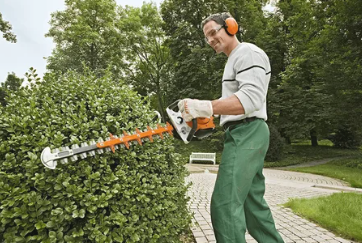

**Переобучение (overfitting)** — это ситуация, когда модель обучается слишком хорошо на обучающих данных, запоминая их детали, включая шум и случайные выбросы. Как видим, дерево способно очень хорошо "запомнить" все детали обучающей выборки и дать почти 100% точность на классификации (на регрессии тоже). Как вы знаете, это плохо скажется на качестве работы алгоритма на новых данных.

Причины переобучения для деревьев:
- **Глубокие деревья**: если не ограничивать максимальную глубину дерева, оно будет продолжать разбиение до тех пор, пока в каждом листе не окажется по одному объекту или пока объекты не будут идеально классифицированы. Это приводит к тому, что дерево становится слишком специфичным для обучающего набора.
- **Разбиение на мелкие группы**: если дерево продолжает разделять данные на очень маленькие группы (листья), оно может начать выделять случайные флуктуации в данных, что ухудшает его способность к обобщению.

### Борьба - Стрижка дерева (pruning)

**Стрижка дерева (pruning)** — это техника уменьшения размера дерева, чтобы предотвратить переобучение. Суть стрижки в том, чтобы удалить (или "состричь") лишние ветви дерева, которые не добавляют значимой информации или, наоборот, ухудшают качество предсказаний на новых данных.

Есть два основных типа стрижки:

1. **Pre-pruning (предварительная стрижка)**: дерево ограничивается во время его роста. В этом случае можно заранее установить ограничения на его максимальную глубину, минимальное количество объектов в каждом узле или минимальный прирост информации при каждом разбиении. Этот подход предотвращает рост дерева до чрезмерной глубины.
   
2. **Post-pruning (пост-стрижка)**: дерево сначала строится полностью, а затем его ветви, которые не приводят к значительному улучшению точности, удаляются. Этот метод эффективен тем, что дерево сначала может "разобраться" в структуре данных, а затем избавиться от лишних деталей. Тема устаревшая и в индустрии почти не используется...

### Пример стрижки дерева

При использовании таких библиотек, как `scikit-learn`, можно контролировать размер дерева с помощью гиперпараметров, таких как `max_depth` (максимальная глубина дерева), `min_samples_split` (минимальное количество объектов для разбиения) или `min_samples_leaf` (минимальное количество объектов в листе). Изучите как следует ДОКУМЕНТАЦИЮ к алгоритмам типа DesicionTree на официальном сайте `sklearn`!



## Data

Поэкспериментируем с датасетом, посвященным сорту риса (Бурый, Белый). Это задача бинарной классификации.

In [ ]:
# Cross-platform data download: works both in Google Colab and locally
# (no !wget / !apt, which are absent on macOS / Windows).
import os
import zipfile
import urllib.request

url = ('https://www.dropbox.com/scl/fi/agnovv5qswaogv8et3ubl/rice_dataset.zip'
       '?rlkey=glr683n55s1m0zqmbhqyuo58a&st=nmr34prg&dl=1')  # dl=1 -> direct download
zip_path = 'rice_dataset.zip'
extract_dir = 'rice_data'

if not os.path.exists(zip_path):
    urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path) as z:
    z.extractall(extract_dir)

# locate the csv anywhere inside the extracted folder
csv_path = next(
    os.path.join(root, f)
    for root, _, files in os.walk(extract_dir)
    for f in files if f.endswith('.csv')
)

rice = pd.read_csv(csv_path).drop('id', axis=1)


In [ ]:
rice

In [ ]:
# @title Не запускайте эту ячейку, иначе вам придется долго ждать!! Ооочень долго!!
# Не запускайте эту ячейку, иначе вам придется долго ждать!!
sns.pairplot(data=rice, hue='Class')

In [ ]:
rice.info()

Видим, что в данных нет пропусков и все признаки числовые. Это очень хорошо. Надо помнить, что при использовании решающего дерева `DecisionTree` от `sklearn` не должно быть:
* Пропусков
* Строковых колонок (с текстом)

Однако деревья чаще всего не нуждаются в масштабировании признаков. Подумайте почему?

> **Ответ:** дерево принимает решения по порогам вида `признак > s` отдельно для каждого признака. Любое монотонное преобразование (в том числе масштабирование) не меняет порядок значений признака, а значит и набор возможных разбиений — поэтому деревьям масштабирование не нужно.

В некоторых случаях можно прологарифмировать таргет (если у нас регрессия), чтобы снизить разброс и укоротить хвосты. Порой это стабилизирует алгоритм и повышает его эффективность.

### Поделим данные на тренировочные и тестовые.

In [ ]:
X = rice.drop('Class', axis=1)
y = rice.Class
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=10)

### Обучим алгоритм при дефолтных гиперпараметрах и оценим качество

**Кстати, вопрос:** можно ли для дерева применять оценку ROC-AUC? Почему?

> **Ответ:** да, можно. ROC-AUC работает не с метками, а с ранжирующими оценками (вероятностями), а дерево их выдаёт через `predict_proba` (доля класса в листе). Нюанс: у одиночного дерева вероятности дискретны — уникальных значений мало, поэтому ROC-кривая получается «ступенчатой», и оценка грубее, чем у ансамблей.

In [ ]:
dtc = tree.DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred_train = dtc.predict(X_train)
y_pred_test = dtc.predict(X_test)

In [ ]:
print('TRAIN:')
print(f'Accuracy: {accuracy_score(y_train, y_pred_train)}')
print(f'F1: {f1_score(y_train, y_pred_train)}')
print('Confusion matrix:')
print(confusion_matrix(y_train, y_pred_train))
print('\nTEST:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_test)}')
print(f'F1: {f1_score(y_test, y_pred_test)}')
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred_test))

Типичненько! Дерево стало "шибко умным", то есть переобучилось. Оно дало 100% результат на обучении и натворило ошибок на тесте. Стоит посмотреть, как меняется соотношение качества на обучении и на тесте при изменении гиперпараметров. Пострижём дерево, господа!

Переберем разные значения по гиперпараметру `max_depth`, который ограничивает рост дерева по количеству разбиений (Пример: если корневой узел разбился на 2 вершины и рост дерева на этом прекратился, то его глубина равна 1):

In [ ]:
from tqdm import tqdm
depths = list(range(1, 41))
error_train_f1 = []
error_test_f1 = []
for max_depth in tqdm(depths):
    dtc = tree.DecisionTreeClassifier(max_depth=max_depth)
    dtc.fit(X_train, y_train)
    y_pred_train = dtc.predict(X_train)
    y_pred_test = dtc.predict(X_test)
    error_train_f1.append(1 - f1_score(y_train, y_pred_train))
    error_test_f1.append(1 - f1_score(y_test, y_pred_test))


In [ ]:
sns.lineplot(x=depths, y=error_train_f1, color='green', label='TRAIN').set_title('Качество алгоритма на обучении и на тесте')
sns.lineplot(x=depths, y=error_test_f1, color='red', label='TEST')
plt.ylabel('ERROR')
plt.xlabel('Max Depth')


Так мы можем отследить такое значение гиперпараметра `max_depth`, при котором будут достигнуты наилучшие показатели на тестовой выборке. Когда дерево продолжит расти дальше, то будет улучшаться прогноз на обучающей выборке и ухудшаться на отложенной.
ВЫВОД - С РОСТОМ СЛОЖНОСТИ АЛГОРИТМА СНИЖАЕТСЯ ЕГО ОБОБЩАЮЩАЯ СПОСОБНОСТЬ!

Другой фактор ограничения - `min_samples_leaf` - минимальное количество объектов в листе. Если оно достигается, то вершина больше не ветвится и становится листом. Если этот фактор не ограничивать, то потенциально дерево может ветвиться до тех пор пока в листе не останется один объект. Чем больше значение этого параметра, тем выше ограничение.

In [ ]:
from tqdm import tqdm
leaf_values = list(range(150, 0, -5))
error_train_f1 = []
error_test_f1 = []
for min_samples_leaf in tqdm(leaf_values):
    dtc = tree.DecisionTreeClassifier(min_samples_leaf=min_samples_leaf)
    dtc.fit(X_train, y_train)
    y_pred_train = dtc.predict(X_train)
    y_pred_test = dtc.predict(X_test)
    error_train_f1.append(1 - f1_score(y_train, y_pred_train))
    error_test_f1.append(1 - f1_score(y_test, y_pred_test))
title = ('Качество алгоритма на обучении и на тесте \n'
         'при различном `min_samples_leaf`')
ax = sns.lineplot(x=leaf_values, y=error_train_f1, color='green', label='TRAIN')
ax.set_title(title)
sns.lineplot(x=leaf_values, y=error_test_f1, color='red', label='TEST')
plt.ylabel('ERROR')
plt.xlabel('min_samples_leaf')
plt.gca().invert_xaxis()  # слева направо растёт сложность модели (лист всё меньше)


Сделайте выводы сами!

# Task

Теперь ваш черед совершить научный прорыв! Думаю, вы уже изучили документацию к алгоритму DecisionTreeClassifier и знаете, какие гиперпараметры также можно "тюнить". Попробуйте подобрать такое сочетание гиперпараметров, при котором алгоритм даст наилучший скор на тесте. Можете использовать `GridSearch`! Помните, что вы также можете выбирать критерий неоднородности. Для любопытства, сравните текущий алгоритм классификации с Логистической Регрессией.

In [ ]:
# your hard work

# Что ещё нам расскажет дерево, или про интерпретацию результатов

Когда мы использовали линейные модели, мы часто смотрели на коэффициенты (при условии, что данные отмасштабированы и использовалась регуляризация) и могли оценивать значимость признаков для предсказания целевой переменной. Это в той или иной степени согласовывалось с коэффициентами корреляции для регрессии или значением t-критерия для классификации. В этом смысле модель играет не только прогностическую роль, но и исследовательскую.

Однако что предложит нам дерево? У всех «деревянных» алгоритмов есть важный атрибут `feature_importances_`.

`feature_importances_` — это атрибут моделей дерева решений, который показывает важность каждого признака (feature) для принятия решений моделью. Важность признаков измеряется тем, насколько каждый признак помогает уменьшить неопределённость (или «неоднородность») данных при разбиении на узлы дерева.

### Как работает `feature_importances_`?

При каждом разбиении в дереве решений выбирается признак, который лучше всего разделяет данные. Это делается на основе критериев, таких как:
- **Энтропия** (Entropy)
- **Критерий Джини** (Gini impurity)
- **Критерий ошибки классификации** (Misclassification error)

Каждый раз, когда происходит разбиение по какому-то признаку, модель смотрит, насколько это разбиение уменьшает неопределённость. Чем больше неопределённость была уменьшена благодаря признаку, тем более значимым считается этот признак.

### Как рассчитывается важность признаков?

- Важность признака измеряется на основе **среднего уменьшения критерия неоднородности** (например, энтропии или критерия Джини) по всем узлам, где этот признак использовался для разбиения.
- Эти уменьшения взвешиваются по количеству объектов, которые попадают в каждую ветвь дерева. То есть разбиение, затрагивающее больше объектов, имеет больший вес.

Важно понимать, что сумма всех значений `feature_importances_` равна 1, так как они нормализованы.

### Как использовать `feature_importances_`?

`feature_importances_` можно использовать для понимания того, какие признаки оказывают наибольшее влияние на предсказания модели. Это полезно для анализа данных, отбора признаков и интерпретации модели.

### Интерпретация:

- **Важные признаки**: признаки с высокой важностью больше всего влияют на предсказания модели. Это те признаки, которые лучше всего разделяют данные при построении дерева.
- **Малозначимые признаки**: признаки с низкими значениями могут оказаться менее полезными или избыточными. Такие признаки можно попробовать исключить для упрощения модели, особенно если они оказывают незначительное влияние.

`feature_importances_` — мощный инструмент для объяснения того, как дерево решений использует входные данные и какие признаки считаются наиболее значимыми для предсказаний.

In [ ]:
dtc = tree.DecisionTreeClassifier(max_depth=6, min_samples_leaf=25)
dtc.fit(X_train, y_train)
feature_importances = dtc.feature_importances_
feature_importances

In [ ]:
sns.barplot(x=feature_importances, y=X.columns, color='black').set_title('Feature importances')
plt.ylabel('Features')

Видим, что модель выделила наиболее значимый признак при полном пренебрежении к остальным... Это может быть симптомом переобученности, но если вы оптимально подобрали гиперпараметры, то значит придется принять неизбежный факт исключительности данного признака.. Тут на самом деле есть смысл использовать алгоритмы-ансамбли деревьев, в которых такая картина менее вероятна, но это это еще предстоит изучить.

Изучим "самый влажный" признак и посмотрим на его t-критерий. Также поступим с наиболее "отвергнутым" признаком.

In [ ]:
from scipy import stats
ttest = stats.ttest_ind(X.loc[y==0, 'MinorAxisLength'], X.loc[y==1, 'MinorAxisLength'])
print(ttest)
info = f"___MinorAxisLength___\n t-criterion: {round(ttest.statistic, 2)}\n p-value: {ttest.pvalue}"
fig, ax = plt.subplots(1, 2, figsize=(10, 7))
sns.boxplot(x=X.MinorAxisLength, hue=y, fill=True, palette='Set2', ax=ax[0])
sns.kdeplot(x=X.MinorAxisLength, hue=y, fill=True, palette='Set2', ax=ax[1])
fig.suptitle(info)

Видим, что «любимый» моделью признак имеет крайне выраженные статистически значимые различия по группирующей переменной. Оценим один из самых малозначимых:

In [ ]:
X.columns[6]

In [ ]:
ttest = stats.ttest_ind(X.loc[y==0, 'Extent'], X.loc[y==1, 'Extent'])
man = stats.mannwhitneyu(X.loc[y==0, 'Extent'], X.loc[y==1, 'Extent'])
print(ttest)
info = f"Extent\n t-criterion: {round(ttest.statistic, 2)}\n p-value: {ttest.pvalue}"
fig, ax = plt.subplots(1, 2, figsize=(10, 7))
sns.boxplot(x=X.Extent, hue=y, fill=True, palette='Set2', ax=ax[0])
sns.kdeplot(x=X.Extent, hue=y, fill=True, palette='Set2', ax=ax[1])
fig.suptitle(info)

Не смотря на то, что по признаку `Extent` также наблюдаются значимые различия, дерево им пренебрегло. Можно заподозрить некорректность результатов t-test в виду ненормальности распределения. Но непараметрический тест тоже говорит о значимых различиях.

```
MannwhitneyuResult(statistic=56968262.5, pvalue=0.0)
```
Вполне возможно, что некотторый вклад в ситуацию вносит наличие выбросов в данных. Хорошо было бы провести эксперимент по очистке данных.
Если хорошо подобрать гиперпараметры модели и почистить данные, может ситуация и изменится, однако факт тот, что у древесных алгоритмов "свой" взгляд на важность признаков и это качество также важно для исследовательских целей.

# Task

Очистите данные от выбросов и обучите модель с наилучшими (теперь это могут быть другие значения) гиперпараметрами. Оцените качество и интерпретируйте результат, оцените важность признаков. Поменялось ли что-то?? Важно отработать эту гипотезу экспериментально.

In [ ]:
# your hard work

# Задача регрессии

Будет очень не лишним изучить [статью от `sklearn`](https://scikit-learn.org/stable/modules/tree.html#tree).


Решающее дерево для регрессии — это алгоритм, который строит модель для предсказания числовой (не категориальной) переменной. Алгоритм разбиения и построения дерева схож с тем, что используется в задачах классификации, но отличается критерием, по которому происходит выбор разбиений и конечных предсказаний.

Пусть множество $R$ - множество объектов наблюдений, которые являются вершиной дерева. После разбиения получаем два множества $R_l$ и $R_r$. В общем виде, любое множество будем называть $R_m$.

## MSE - среднеквадратичная ошибка

$$H(R_m) = \frac{1}{|R_m|}\sum_{y\in R_m} (y - \overline{y}_m)^2$$

Где $\overline{y}_m$ - среднее значение целевой переменной для данного множества.

## Poisson - среднее отклонение Пуассона

$$H(R_m) = \frac{2}{|R_m|}\sum_{y\in R_m} (y \ln{\frac{y}{\overline{y}_m}} - y + \overline{y}_m)$$

Почитайте в статье, в каких случаях он предпочтительнее!

## MAE - средняя абсолютная ошибка

$$H(R_m) = \frac{1}{|R_m|}\sum_{y\in R_m} |y - median(y_m)|$$

Также прочтите в статье о целесообразности применения этого функционала разбиения.

## Алгоритм работы дерева для регрессии:

1. Для каждой возможной точки разбиения $t$ выбираем признак $x_j$, по которому производится разбиение, и делим набор данных на две части: $R_l$ (левая часть) и $R_r$ (правая часть).
2. Для каждой из этих частей вычисляется среднее значение целевой переменной $\overline{y}_l$ и $\overline{y}_r$. Эти значения являются выходными (предсказанными) для каждой вершины.

3. Общее качество для разбиения (аналог Impurity) рассчитывается как сумма ошибок для левой и правой частей, взвешенных по количеству объектов в каждой части:

$$Q_t(R, j, s) = \frac{|R_l|}{|R|} H(R_l) + \frac{|R_r|}{|R|} H(R_r) \to min_{j, s}$$



## Пример с криволинейной зависимостью.

Даны 100 наблюдений в одномерном признаковом пространстве, объясняющих некоторую вещественную величину. Зависимость описывается некоторым криволинейным законом и не имеет шума.

In [ ]:
X = np.linspace(-.5*np.pi, np.pi, 100)
y = np.cos(X) + 1.5
plt.plot(X, y, label="$y = \cos{x} + 1.5$", c='black')
plt.grid()
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title('Тригонометрический закон')

Если текущий набор данных представим в виде множества $R = \{(x_i, y_i)\}_{i=1}^n$ входящего в корневой узел, то предлагаю ознакомиться с симулятором логического деления данного узла:

In [ ]:
# @title Симулятор разделения по количественному признаку в задаче регрессии
from ipywidgets import interact, FloatSlider

lo = -.5 * np.pi + .01
hi = np.pi - .01

def tr_data(x_tr: float) -> tuple:
    '''split data by the threshold; return the two means and the two target arrays'''
    y_left = y[X < x_tr]
    y_right = y[X >= x_tr]
    return y_left.mean(), y_right.mean(), y_left, y_right

def MSE(v: np.ndarray) -> float:
    return ((v - v.mean()) ** 2).mean()

def MAE(v: np.ndarray) -> float:
    return np.abs(v - np.median(v)).mean()

def poisson(v: np.ndarray) -> float:
    return (v * np.log(v / v.mean()) - v + v.mean()).sum() * 2 / v.shape[0]

def Qual(x_tr: float) -> tuple:
    y_l_mean, y_r_mean, y_l, y_r = tr_data(x_tr)
    n = len(X)
    mse = (y_l.shape[0] * MSE(y_l) + y_r.shape[0] * MSE(y_r)) / n
    mae = (y_l.shape[0] * MAE(y_l) + y_r.shape[0] * MAE(y_r)) / n
    pois = (y_l.shape[0] * poisson(y_l) + y_r.shape[0] * poisson(y_r)) / n
    return y_l_mean, y_r_mean, mse, mae, pois

tr_plot = np.linspace(lo, hi, 50)
qu = np.vectorize(Qual)(tr_plot)
mse_plot, mae_plot, pois_plot = qu[2], qu[3], qu[4]

def update_plot(threshold):
    threshold = float(threshold)
    y_l_mean, y_r_mean, mse, mae, pois = Qual(threshold)
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    sns.lineplot(x=X, y=y, color='black', ax=ax[0]).set_title('Зависимость целевой переменной от числового признака.')
    ax[0].axvline(threshold, color='black', linestyle='--', label=f'Порог: {round(threshold, 2)}')
    sns.lineplot(x=[lo, threshold], y=[y_l_mean, y_l_mean], color='red', ax=ax[0], label=f'PREDICT IF TRUE: {round(y_l_mean, 2)}')
    sns.lineplot(x=[threshold, hi], y=[y_r_mean, y_r_mean], color='green', ax=ax[0], label=f'PREDICT IF FALSE: {round(y_r_mean, 2)}')
    ax[0].set_xlabel('X')
    ax[0].set_ylabel('y')
    sns.lineplot(x=tr_plot, y=mse_plot, color='green', ax=ax[1], label=f'MSE: {round(mse, 2)}').set_title('Функционал качества разбиения $Q_t(R, j, s)$.')
    sns.lineplot(x=tr_plot, y=mae_plot, color='blue', ax=ax[1], label=f'MAE: {round(mae, 2)}')
    sns.lineplot(x=tr_plot, y=pois_plot, color='magenta', ax=ax[1], label=f'POISSON: {round(pois, 2)}')
    ax[1].set_xlabel('Значение порога')
    ax[1].set_ylabel('Качество')
    ax[1].scatter([threshold] * 3, [mse, mae, pois], color='red', s=60)
    plt.show()

interact(update_plot, threshold=FloatSlider(value=0, min=lo, max=hi, step=.01, description='Порог'));


Если мы в этом симуляторе подберем наилучший порог, то мы так построим дерево глубиной 1, которое сможет уже как-то предсказывать нашу целевую количественную переменну. Покажем это в виде схемы:

In [ ]:
# @title Узловая вершина
clf = tree.DecisionTreeRegressor(max_depth = 1)
clf = clf.fit(X.reshape((X.shape[0], 1)), y)
tree.plot_tree(clf)

Изучите данную отрисовку. Что она нам показывает?

### Ступенчатое приближение.

Вывод: при однократном разделении корневого узла в задаче регрессии мы получаем возможность предсказывать только две константы — два усреднённых значения целевой переменной для левого и правого множества. Мы получаем СТУПЕНЧАТОЕ ПРИБЛИЖЕНИЕ! Чтобы точнее аппроксимировать эту условную зависимость, необходимо увеличить число ступенек, то есть дать дереву вырасти глубже. Пример для того же тригонометрического закона:

In [ ]:
# @title Точность и глубина
from ipywidgets import interact, IntSlider

XX = X.reshape((X.shape[0], 1))

def update_plot(max_depth):
    clf = tree.DecisionTreeRegressor(max_depth=int(max_depth))
    clf.fit(XX, y)
    y_pred = clf.predict(XX)
    plt.plot(X, y, label=r"$y_{true} = \cos{x} + 1.5$", c='black')
    plt.plot(X, y_pred, label=f"y predict\nRMSE: {round(((y - y_pred) ** 2).mean() ** .5, 4)}", c='red')
    plt.grid()
    plt.legend()
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('Приближение тригонометрического закона')
    plt.show()

interact(update_plot, max_depth=IntSlider(value=2, min=1, max=15, step=1, description='Max depth'));


Во всей красе мы увидили поведение алгоритма в задаче регрессии. При достаточной сложности алгоритма, он способен описать практически любую криволинейную зависимость.

## Гауссовский шум и регрессионное дерево (Gaussian noise)

Предыдущий пример показывает поведение алгоритма на криволинейной зависимости идеального вида. В природе так не бывает: данные всегда зашумлены, и нам необходимо посмотреть на работу дерева с данными, имеющими некоторый шум.

Ниже предложен интерактивный симулятор обучения регрессионного «деревянного» алгоритма с возможностью изменять глубину дерева. Показан классический пример с оценкой модели на обучающей и тестовой выборках. Поэкспериментируйте с ним и внимательно изучите особенности его работы.

In [ ]:
# @title Точность и глубина
from ipywidgets import interact, IntSlider
from sklearn.metrics import mean_squared_error

X = np.linspace(-.5 * np.pi, 2 * np.pi, 100)
X_test = X + .1
y_train = np.cos(X) + np.random.randn(100) * .4
y_test = np.cos(X + .05) + np.random.randn(100) * .2

XX = X.reshape((X.shape[0], 1))
XX_test = X_test.reshape((X.shape[0], 1))

def update_plot(max_depth):
    clf = tree.DecisionTreeRegressor(max_depth=int(max_depth))
    clf.fit(XX, y_train)
    y_train_predict = clf.predict(XX)
    y_test_predict = clf.predict(XX_test)
    loss = pd.Series({'MSE_Train': mean_squared_error(y_train, y_train_predict),
                      'MSE_Test': mean_squared_error(y_test, y_test_predict)})

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    sns.scatterplot(x=X, y=y_train, label='TRAIN DATA', color='black', ax=ax[0])
    sns.lineplot(x=X, y=y_train_predict.ravel(), color='red', label='Predict on Train', ax=ax[0])
    ax[0].set_xlabel('$X_{train}$')
    ax[0].set_ylabel('$y_{train}$')

    sns.scatterplot(x=X_test, y=y_test, label='TEST DATA', color='green', ax=ax[1])
    sns.lineplot(x=X_test, y=y_test_predict.ravel(), color='red', label='Predict on Test', ax=ax[1])
    ax[1].set_xlabel('$X_{test}$')
    ax[1].set_ylabel('$y_{test}$')

    sns.barplot(x=loss.index, y=loss, color='black', ax=ax[2])
    ax[2].set_xlabel('Mode')
    ax[2].set_ylabel('Loss')
    ax[2].set_ylim(0, .6)

    fig.suptitle('Приближение зашумлённого тригонометрического закона')
    plt.show()

interact(update_plot, max_depth=IntSlider(value=2, min=1, max=15, step=1, description='Max depth'));


Итак, какие вы сделали выводы? Сначала сделайте свои выводы, а потом читайте далее. Лично я заметил:
* Достаточно быстрая переобучаемость
* Переобученный алгоритм плохо прогнозирует на тестовых данных но дает исчезающе малую ошибку на тренировочных.
* Наблюдения, которые сильнее отклоняются от тренда провоцирует алгоритм делать "Пики" на ломанной линии. Это тот пример "запоминания" деревом специфических флуктуаций в данных с которым также можно бороться ограничивая минимальное количество объектов в листе. Выбросы очень любят "уединяться" в терминальных вершинах (листьях)! Также на НЕСТАБИЛЬНОСТЬ может влиять тот факт, что мы использовали функционал качества MSE. Мы со времен линейных моделей помним его "любовь" к большим отклонениям. Выбросы + MSE - это рецепт как свести алгоритм с ума...

Возникает в уме гипотеза, что, может быть, MAE немного стабилизирует алгоритм? Надо проверять...

In [ ]:
# @title Точность и глубина
from ipywidgets import interact, IntSlider

X = np.linspace(-2 * np.pi, 2 * np.pi, 100)
y = np.cos(X) * 2 + np.random.randn(100) * .6 + 2

XX = X.reshape((-1, 1))

def update_plot(max_depth):
    d = int(max_depth)
    clf = tree.DecisionTreeRegressor(max_depth=d)
    clf.fit(XX, y)
    y_pred = clf.predict(XX)

    clf_mae = tree.DecisionTreeRegressor(max_depth=d, criterion='absolute_error')
    clf_mae.fit(XX, y)
    y_pred_mae = clf_mae.predict(XX)

    plt.subplots(figsize=(8, 6))
    sns.scatterplot(x=X, y=y, label=r"$y_{true} = \cos{x} \cdot 2 + 2 + \epsilon$", color='black')
    plt.plot(X, y_pred, label="Algorithm MSE", c='red')
    plt.plot(X, y_pred_mae, label="Algorithm MAE", c='green')
    plt.grid()
    plt.legend()
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('Приближение тригонометрического закона')
    plt.show()

interact(update_plot, max_depth=IntSlider(value=2, min=1, max=15, step=1, description='Max depth'));


Позапускав этот симулятор несколько раз, напрашивается вывод, что до определенного момента MAE ведет себя в некоторой мере стабильнее. Именно в некоторой мере и не везде, однако некоторые пики все таки сглаживаются. Все это делает целесообразным при обучении модели на реальных данных тестирование алгоритма используя различные функционалы качества.

# Выводы

Если вы честно дошли до этого раздела, значит вы проделали огромную работу! Не забудьте себя поощрить и похвалить! Деревья - это очень интересный подход в решении прогностических задач в машинном обучении. Он не сказать чтобы был сильно новым.. Зарождалась эта метода в 50-х годах. Тем не менее, даже сейчас нет-нет да придумывают еще более совершенный алгоритм на основе решающего дерева. Вариаций на тему очень много, но в основе лежат те идеи, с которыми мы познакомились в этом конспекте.

Озаботьтесь практикой! Вам предложен (и будут предложены еще) проектные работы, в рамках которых не забывайте использовать деревья и все подходы, с которыми мы тут познакомились. Желаю успехов!